In [1]:
# You may add additional imports here
import random
import matplotlib.pyplot as plt
import csv

Question 1
==========

All parts of Question 1 use the _point-a-rally (PARS) scoring_ system.

**Question 1a:** Complete the following function so that it implements the PARS algorithm from the coursework specification.

**[Functionality: 7 marks]**

In [2]:
def game(ra, rb):
    score_a, score_b = 0, 0
    
    while score_a < 11 and score_b < 11:
        if random.random() < ra / (ra + rb):
            score_a += 1
        else:
            score_b += 1

    return score_a, score_b


**Testing:** If the random seed is set to 57, then calling the function with arguments `70` and `30` should return `(11,5)`.

In [3]:
random.seed(57)
print(game(70, 30))

(11, 5)


**Question 1b:** Complete the following function `win_probability_game(ra, rb, simulations)` to simulate `simulations` games in order to estimate the probability that a player with ability `ra` will win a game against a player of ability `rb`.

**[Functionality: 4 marks]**

In [4]:
def win_probability_game(ra, rb, simulations):
    wins_a, wins_b = 0, 0

    for _ in range(simulations):
        score_a, score_b = game(ra, rb)
        if score_a > score_b:
            wins_a += 1
        elif score_b > score_a:
            wins_b += 1

    total = wins_a / (wins_b + wins_a)
    total = round(total, 2)  
    return total


**Testing:** Given sufficient simulations, calling the function with abilities `70` and `30` should give the answer `0.98` when printed to 2 decimal places.

In [5]:
# Print win_probability_game(70, 30) to 2 decimal places for a suitable value of n:
print(round(win_probability_game(70, 30, 100000), 2))

0.97


**Question 1c:** Assume players abilities are given in a csv file with the format:
```
player a ability, player b ability,
60, 20,
100, 55,
50, 40,
20, 70,
95, 85,
```
Complete the following function to read in a specified csv file of this format and return a `list` of `tuple`s containing each pair of abilities.

**[Functionality: 4 marks]**

In [6]:
def read_abilities(filename):
    with open(filename, 'r') as file:
        abilities_reader = csv.reader(file)
        next(abilities_reader)  
        ability_list = [(int(row[0]), int(row[1])) for row in abilities_reader]
        return ability_list


**Testing:** Calling the function to read the file `test.csv` from Learning Central should return `[(60, 20), (100, 55), (50, 40), (20, 70), (95, 85)]`

In [7]:
file_path = 'test.csv'  
abilities_result = read_abilities(file_path)
print(abilities_result)

[(60, 20), (100, 55), (50, 40), (20, 70), (95, 85)]


**Question 1d:** Write a function that takes a `list` of the format returned by your answer to 1c as an argument, and uses `matplotlib` to produce a plot (with labelled axes) showing the probability that player a beats player b (in a game) against `ra / r_b` for each pair.

**[Functionality: 5 marks]**

In [8]:
def plot_win_probabilities(data):
    x_list = [ra / rb for ra, rb in data]
    y_list = [win_probability_game(ra, rb, 500) for ra, rb in data]

    plt.plot(x_list, y_list, 'o')
    plt.xlabel('ra/rb')
    plt.ylabel('Probability A wins')
    plt.show()


**Testing:** The following figure (or similar) should result from the data `[(60, 20), (100, 55), (50, 40), (20, 70), (95, 85)]'

<img src="./win_probabilities.png" alt="Win probabilities" width="500">


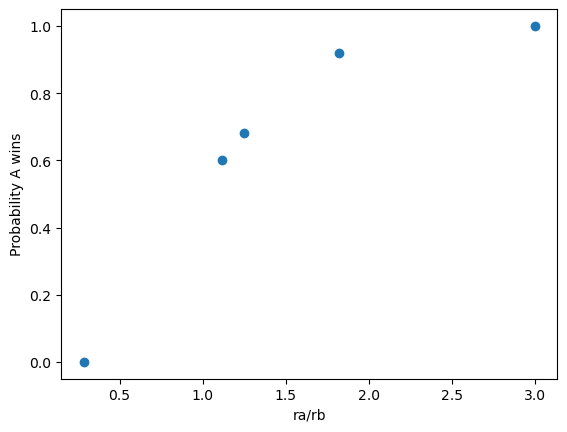

In [9]:
## Call the function to plot the figure here
abilities_list = [(60, 20), (100, 55), (50, 40), (20, 70), (95, 85)]
plot_win_probabilities(abilities_list)

**Question 1e:** Complete the following function `win_probability_match(ra, rb, simulations, m)` to simulate `simulations` matches which are won by the first player to win `m` games, and returns an estimate of the probability that a player with ability `ra` will win such a match against a player of ability `rb`.

Provide code that works out the smallest value of `m` such that `win_probability_match(60, 40, simulations, m)` is at least `0.9`. 

_HINT: make sure you use an appropriate value for `simulations`._

**[Functionality: 5 marks]**

In [ ]:
def win_probability_match(ra, rb, simulations, m):
    wins_a = 0

    for _ in range(simulations):
        games_a = 0
        game_over = False

        while not game_over:
            score_a, _ = game(ra, rb)
            if score_a:
                games_a += 1

            if games_a >= m:
                wins_a += 1
                game_over = True

    probability = wins_a / simulations
    return probability

def smallest_match(ra, rb, simulations, m_h):
    smallest_m = m_h

    for m in range(m_h, 0, -1):
        probability = win_probability_match(ra, rb, simulations, m)

        if probability >= 0.9:
            smallest_m = m

    return smallest_m

result = smallest_match(60, 40, 500, 100)
print(result)


Question 2
==========

Complete the remaining template of a scientific report that uses the results of simulation (with suitable input data) to investigate whether English or PARS is the ``better'' scoring method for squash matches. 

You should clearly state any assumptions you make, and may add any number of code cells. Guidance for completing the markdown/text cells is given in the coursework specification. The word count of the remaining markdown/text cells must be at most 750.

Your investigation should consider the relative ability of the two players (i.e. `ra/rb`) as the _independent variable_ and include appropriate figures that show how your choice of relevant _dependent variable_ varies. Your results **must** cover at least 50 different values of `ra/rb`.

Some starting points you may consider:
- How _fair_ is the scoring method - does the better player usually win?
- Shorter matches are usually preferable (e.g. for television) - if you assume each rally in a match takes equal time, how long do matches typically last?
- What effect does the relative ability of the two players have?

**[Report: 7 marks; Achievement: 8 marks]**

## Problem

In order to asses which scoring method of PARS and english squash is better, we will need to look at factors such as the fairness and how bias the method is. Therefore we will assesss which method is "better" by looking at how well each method aligns with expected outcomes.

## Method

to determine which method is better we will run different simulations of each method of squash which will calculate the amount of rallies per game for English and PARS and calculating the win probabliltes and their correlation with player ability ratios where player A skill level ranges from 50 to 150 and player B stays at 75. i will run 75,000 simulations for each scoring method which will help increase accuracy and using matplotilb to visulaise it by plotting a graph.

In [ ]:
import random
import matplotlib.pyplot as plt

def game_rallies(ra, rb):
    probability_a = ra / (ra + rb)
    score_a = 0
    score_b = 0
    rallies = 0
    while (score_a != 11 and score_b <= 9) or (score_b != 11 and score_a <= 9):
        rallies += 1
        r_number = random.random()
        if probability_a > r_number:
            score_a += 1
        else:
            score_b += 1
    return score_a, score_b, rallies

def english_game(ra, rb):
    score_a = 0
    score_b = 0
    game_over = False
    english_rallies = 0
    server = random.choice(['a', 'b'])
    win_score = 9

    probability_a = ra / (ra + rb)

    while not game_over:
        english_rallies += 1
        r_number = random.random()
        if server == 'a':
            if probability_a > r_number:
                score_a += 1
            else:
                score_b += 1
                server = 'b'
        if server == 'b':
            if probability_a > r_number:
                score_a += 1
                server = 'a'
            else:
                score_b += 1
        if score_a == 8 and score_b == 8:
            win_score = random.choice([9, 10])
        elif score_a == win_score or score_b == win_score:
            game_over = True
    return score_a, score_b, english_rallies

def simulate_match(ra, rb, simulations, scoring_method):
    a_wins = 0

    for _ in range(simulations):
        if scoring_method == 'english':
            win = english_game(ra, rb)
            if win[0] >= win[1]:
                a_wins += 1
        elif scoring_method == 'pars':
            win = game_rallies(ra, rb)
            if win[0] >= win[1]:
                a_wins += 1

    probability_a = a_wins / simulations
    return probability_a

def plot_simulations():
    x_values = list(range(50, 151, 10))
    y_values_pars = [simulate_match(ra, 75, 75000, 'pars') for ra in x_values]
    y_values_english = [simulate_match(ra, 75, 75000, 'english') for ra in x_values]

    plt.plot(x_values, y_values_pars, 'o', label='PARS')
    plt.plot(x_values, y_values_english, 'o', label='English')
    plt.xlabel('Player A Skill Level (ra)')
    plt.ylabel('Probability Player A Wins')
    plt.legend()
    plt.title("Probability Player A Wins vs. Player A Skill Level")
    plt.show()




    
       

   




  





       






## Assumptions

some assumptions i have made are that both players consistently perform at their highest ability throughout the entire duration of each match with no external factors affecting them like an injury

## Results

In [ ]:
plot_simulations()

the graph shows that player A is more likely to win with the PARS scoring method than the english method. as player A skills level increases, the hance of winning consistently rises with PARS, while the english method shows a straight constant line showing a stable winning probability. therefore, this graph and simulation suggests the PARS is more effective.

## Conclusions

my method has given me insight into which scoring method is better through analysing the fairness of the methods and rally count per game. However this could be probably imporoved by adding more simulations and more data which would give me a more accurate conclusion